## 1. Estructura de Datos

**Variables principales detectadas:**
- `measured_on`: Timestamp de la medición.
- Por cada inversor (ej. `inv_01`), se tienen 5 columnas:
  - `dc_current`: Corriente Directa.
  - `dc_voltage`: Voltaje Directo.
  - `ac_current`: Corriente Alterna.
  - `ac_voltage`: Voltaje Alterno.
  - `ac_power`: Potencia AC (**Variable Objetivo** para el modelo Supervisado).

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Leer el dataset completo
df = pd.read_csv('2107_electrical_data.csv')

# Obtener dimensiones dinámicamente
filas, columnas = df.shape
print(f"Dimensión del Dataset: {filas:,} filas y {columnas} columnas.")


Dimensión del Dataset: 632,952 filas y 120 columnas.


## 2. Exploración de Datos (EDA) y Limpieza
Para este EDA los datos con 0W se asumieron como datos noctornus, y no funcionan como tal para determinar el funcionamiento de los inversores, ya que nocturnamente no funciona como tal.

In [2]:
# Convertir a datetime y establecer como índice
df['measured_on'] = pd.to_datetime(df['measured_on'])
df.set_index('measured_on', inplace=True)

# Imprimir tamaño original
print(f"Filas originales: {df.shape[0]:,}")

# Filtrar horas de luz (ej. 06:00 a 19:00)
# Esto remueve automáticamente la noche donde todo es 0W
df_dia = df.between_time('06:00', '19:00').copy()

print(f"Filas después del filtro diurno: {df_dia.shape[0]:,}")
print(f"Se eliminaron {df.shape[0] - df_dia.shape[0]:,} filas ({(df.shape[0] - df_dia.shape[0])/df.shape[0]*100:.1f}%) correspondientes a la noche.")


Filas originales: 632,952
Filas después del filtro diurno: 345,086
Se eliminaron 287,866 filas (45.5%) correspondientes a la noche.


### Comportamiento Diario del Parque Solar
Agrupamos la potencia generada por los 24 inversores para analizar el rendimiento promedio sin saturar la gráfica.

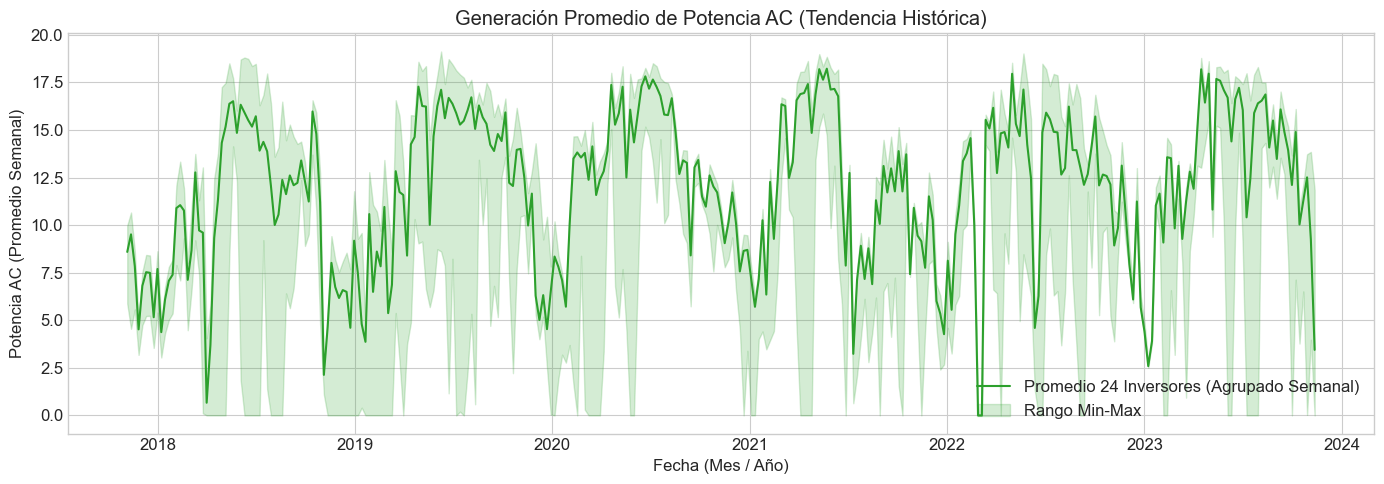

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (14, 5),
    'figure.dpi': 100
})

# Obtener todas las columnas de potencia AC
cols_ac_power = [col for col in df_dia.columns if 'ac_power' in col]

# Crear una columna con el promedio de potencia AC de todo el parque
df_dia['mean_ac_power'] = df_dia[cols_ac_power].mean(axis=1)

# SUB-MUESTREO (RESAMPLING): 
# En lugar de graficar datos cada 5 minutos a lo largo de 6 años (lo cual satura la gráfica),
# se calcula el promedio SEMANAL ('W') para ver las tendencias macro y estacionalidad.
df_semanal = df_dia[['mean_ac_power'] + cols_ac_power].resample('W').mean()

plt.figure()
# Graficar la tendencia promedio semanal
plt.plot(df_semanal.index, df_semanal['mean_ac_power'], label='Promedio 24 Inversores (Agrupado Semanal)', color='#2ca02c')

# Llenar el rango entre el inversor que menos produjo y el que más produjo esa semana
plt.fill_between(df_semanal.index, 
                 df_semanal[cols_ac_power].min(axis=1), 
                 df_semanal[cols_ac_power].max(axis=1), 
                 alpha=0.2, color='#2ca02c', label='Rango Min-Max')

plt.title('Generación Promedio de Potencia AC (Tendencia Histórica)')
plt.xlabel('Fecha (Mes / Año)')
plt.ylabel('Potencia AC (Promedio Semanal)')
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de Degradación a Largo Plazo
Al observar la gráfica anterior, se intuye una ligera caída en los picos de generación de verano de 2018 frente a los de 2023. A continuación, se aplicará una Media Móvil Anual y una línea de tendencia polinomial para comprobar matemáticamente la degradación física natural de los paneles solares.

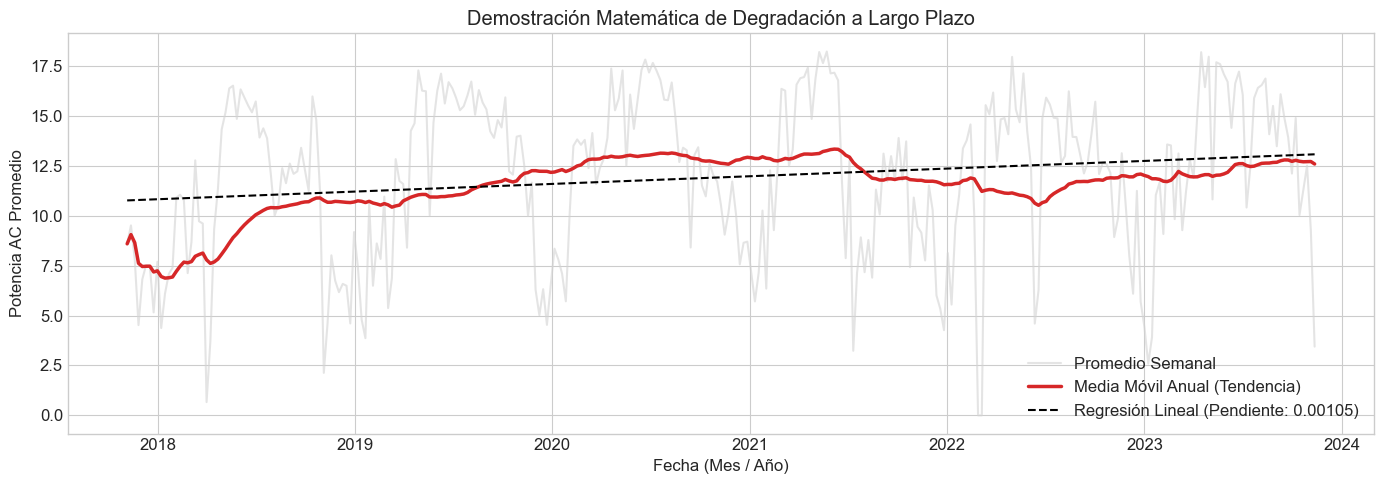

Resultado Analítico: La línea de regresión confirma una degradación total estimada del 21.45% a lo largo de los 6 años de operación.


In [ ]:
import numpy as np

plt.figure(figsize=(14, 5))

# 1. Graficar el promedio semanal tenue en el fondo
plt.plot(df_semanal.index, df_semanal['mean_ac_power'], label='Promedio Semanal', color='lightgray', alpha=0.6)

# 2. Calcular y graficar la Media Móvil Anual (52 semanas)
# Se usa min_periods=1 para que no quede vacía la primera parte del año
media_anual = df_semanal['mean_ac_power'].rolling(window=52, min_periods=1).mean()
plt.plot(df_semanal.index, media_anual, label='Media Móvil Anual (Tendencia)', color='#d62728', linewidth=2.5)

# 3. Línea de tendencia matemática (Regresión Lineal Simple sobre la media)
# Se convierte fechas a números enteros (días desde la primera fecha) para poder ajustar una recta
x_num = (df_semanal.index - df_semanal.index[0]).days
y = df_semanal['mean_ac_power'].bfill() # Rellenar nulos para la regresión
z = np.polyfit(np.array(x_num).flatten(), np.array(y).flatten(), 1) # Regresión de grado 1 (recta)
p = np.poly1d(z)

# Graficamos la recta de regresión
plt.plot(df_semanal.index, p(x_num), label=f'Regresión Lineal (Pendiente: {z[0]:.5f})', color='black', linestyle='--')

plt.title('Demostración Matemática de Degradación a Largo Plazo')
plt.xlabel('Fecha (Mes / Año)')
plt.ylabel('Potencia AC Promedio')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión impresa
perdida_estimada = (p(x_num[-1]) - p(x_num[0])) / p(x_num[0]) * 100
print(f"Resultado Analítico: La línea de regresión confirma una degradación total estimada del {perdida_estimada:.2f}% a lo largo de los 6 años de operación.")


### Análisis de Correlación (DC vs AC)
Extraer las variables de un inversor representativo (Inversor 01) para demostrar matemáticamente la correlación lineal entre voltaje/corriente de entrada y la potencia de salida.

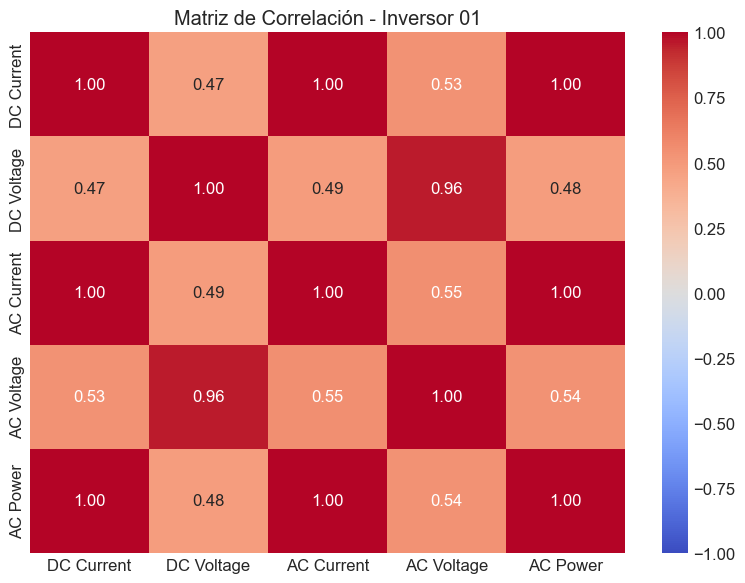

In [5]:
# Variables del Inversor 1
cols_inv1 = [col for col in df_dia.columns if 'inv_01' in col]
df_inv1 = df_dia[cols_inv1]

# Renombrar temporalmente para que la gráfica sea legible en LaTeX
nombres_limpios = {
    'inv_01_dc_current_inv_149579': 'DC Current',
    'inv_01_dc_voltage_inv_149580': 'DC Voltage',
    'inv_01_ac_current_inv_149581': 'AC Current',
    'inv_01_ac_voltage_inv_149582': 'AC Voltage',
    'inv_01_ac_power_inv_149583': 'AC Power'
}
df_inv1_clean = df_inv1.rename(columns=nombres_limpios)

plt.figure(figsize=(8, 6))
sns.heatmap(df_inv1_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Inversor 01')
plt.tight_layout()
plt.show()


### Detección de Anomalías (Outliers por Inversor)
Para identificar si algún inversor está fallando, se suma la producción total diaria de cada inversor y se utiliza un Boxplot estadístico.

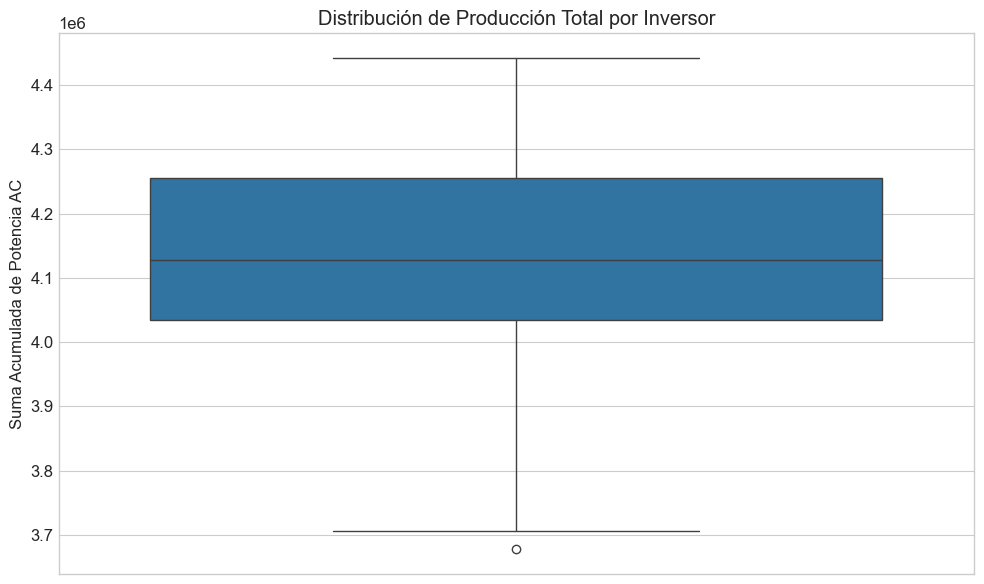

Límite inferior estadístico: 3,702,773.74
¡ALERTA! Se detectaron inversores con bajo rendimiento (posible falla/sombra):
- inv_06_ac_power_inv_149608: 3,677,316.42


In [ ]:
# Calcular energía total producida por día por cada inversor
# Resamplear por día ('D') y sumamos la potencia
energia_diaria = df_dia[cols_ac_power].resample('D').sum()

# Calcular el promedio de energía producida en todo el mes por cada inversor
produccion_total = energia_diaria.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.boxplot(y=produccion_total)
plt.title('Distribución de Producción Total por Inversor')
plt.ylabel('Suma Acumulada de Potencia AC')
plt.tight_layout()
plt.show()

# Detectar matemáticamente quién está por debajo del rango normal
Q1 = produccion_total.quantile(0.25)
Q3 = produccion_total.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR

inversores_fallando = produccion_total[produccion_total < limite_inferior]
print(f"Límite inferior estadístico: {limite_inferior:,.2f}")
if len(inversores_fallando) > 0:
    print("¡ALERTA! Se detectaron inversores con bajo rendimiento (posible falla/sombra):")
    for inv, val in inversores_fallando.items():
        print(f"- {inv}: {val:,.2f}")
else:
    print("No se detectaron inversores anómalos severos según el rango intercuartílico.")


### Análisis Espacio-Temporal
Para entender los patrones intradiarios y descartar sombras locales o fallas térmicas, se va  a crear un Heatmap cruzando los meses del año contra las horas del día.

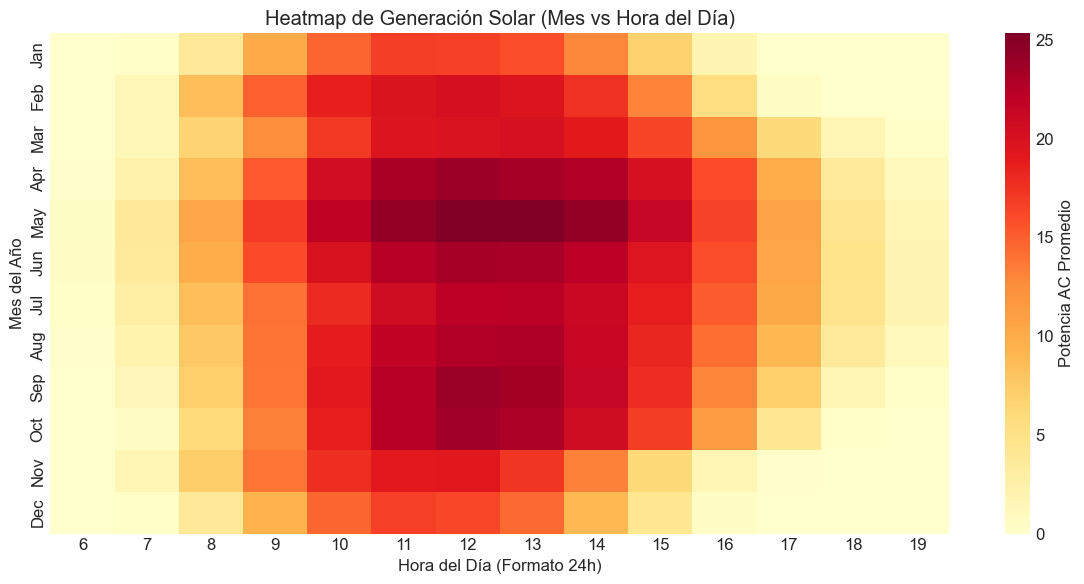

In [7]:
import calendar

# Extraer hora y mes del índice
df_dia['hora'] = df_dia.index.hour
df_dia['mes'] = df_dia.index.month

# Crear tabla pivote: Promedio de potencia AC por Mes y por Hora
pivot_solar = df_dia.pivot_table(values='mean_ac_power', index='mes', columns='hora', aggfunc='mean')

# Cambiar números de meses por nombres
pivot_solar.index = [calendar.month_abbr[i] for i in pivot_solar.index]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_solar, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Potencia AC Promedio'})
plt.title('Heatmap de Generación Solar (Mes vs Hora del Día)')
plt.xlabel('Hora del Día (Formato 24h)')
plt.ylabel('Mes del Año')
plt.tight_layout()
plt.show()


### Cacería de Anomalías: Ranking Matemático de Eficiencia
Antes de aplicar K-Means, se va a calcular la "Eficiencia de Conversión Cruda" de cada inversor dividiendo su salida AC entre su entrada DC ($Voltaje \times Corriente$). Esto permitirá aislar visualmente a los peores actores del parque solar.

Inversor 05 descartado por falta de sensores (ej. sensor DC Voltage roto).


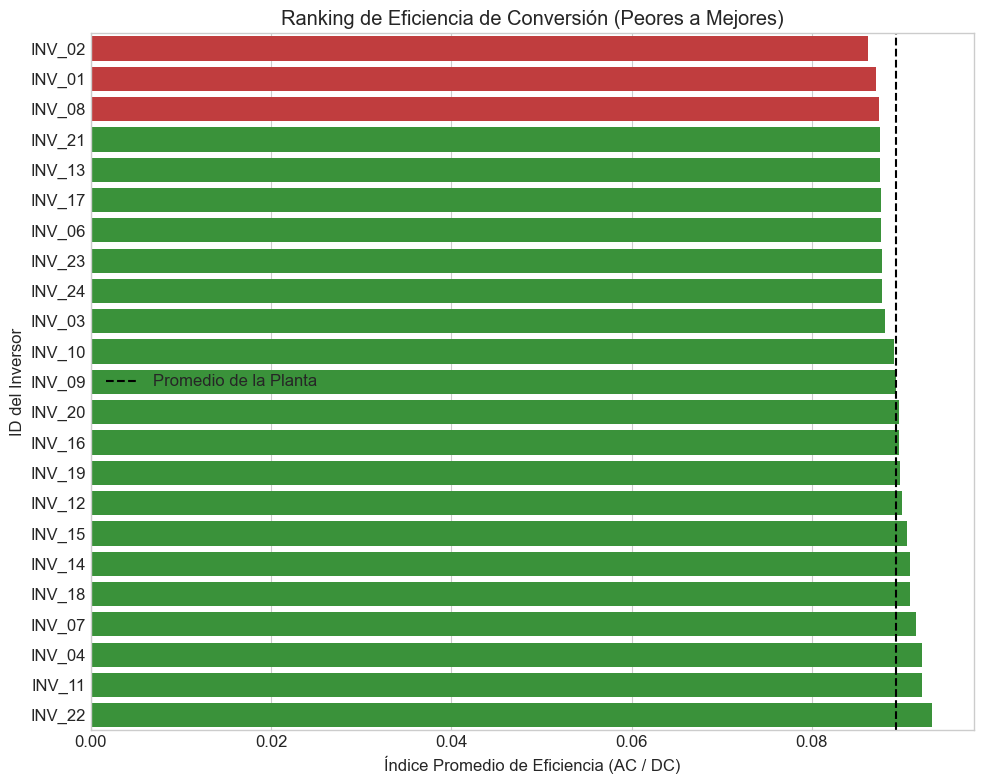

Alerta: Según el cálculo matemático duro, los inversores más ineficientes son: INV_02, INV_01, INV_08


In [ ]:
# Calcular la eficiencia de cada inversor
eficiencias = {}
inversores_ids = sorted(list(set([c.split('_')[1] for c in df_dia.columns if c.startswith('inv_')])))

for inv_id in inversores_ids:
    # Buscar columnas de manera segura
    cols_v = [c for c in df_dia.columns if f'inv_{inv_id}_dc_voltage' in c]
    cols_c = [c for c in df_dia.columns if f'inv_{inv_id}_dc_current' in c]
    cols_p = [c for c in df_dia.columns if f'inv_{inv_id}_ac_power' in c]
    
    if not cols_v or not cols_c or not cols_p:
        print(f"Inversor {inv_id} descartado por falta de sensores (ej. sensor DC Voltage roto).")
        continue
        
    col_dc_v = cols_v[0]
    col_dc_c = cols_c[0]
    col_ac_p = cols_p[0]
    
    # Calcular la potencia de entrada (DC) y evitar división por cero
    potencia_dc = df_dia[col_dc_v] * df_dia[col_dc_c]
    # Se filtra cuando la entrada DC es mayor a 0 para no tener infinitos/nulos
    filtro_activo = potencia_dc > 0
    
    # Índice de eficiencia promedio (AC / DC)
    # Nota: Se usa un factor multiplicador arbitrario (x100) para hacer el índice legible
    eficiencia_promedio = (df_dia.loc[filtro_activo, col_ac_p] / potencia_dc.loc[filtro_activo]).mean() * 100
    eficiencias[f'INV_{inv_id}'] = eficiencia_promedio

# Crear DataFrame y ordenar de peor a mejor
df_eficiencia = pd.DataFrame.from_dict(eficiencias, orient='index', columns=['Indice_Eficiencia']).sort_values('Indice_Eficiencia')

plt.figure(figsize=(10, 8))
# Colorear rojo los 3 peores, verde los demás
colores = ['#d62728' if i < 3 else '#2ca02c' for i in range(len(df_eficiencia))]

sns.barplot(x=df_eficiencia['Indice_Eficiencia'], y=df_eficiencia.index, palette=colores)
plt.title('Ranking de Eficiencia de Conversión (Peores a Mejores)')
plt.xlabel('Índice Promedio de Eficiencia (AC / DC)')
plt.ylabel('ID del Inversor')
plt.axvline(x=df_eficiencia['Indice_Eficiencia'].mean(), color='black', linestyle='--', label='Promedio de la Planta')
plt.legend()
plt.tight_layout()
plt.show()

# Imprimir los 3 peores
peores = df_eficiencia.head(3).index.tolist()
print(f"Alerta: Según el cálculo matemático duro, los inversores más ineficientes son: {', '.join(peores)}")


## 3. Preparación e Ingeniería de Variables


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Crear un DataFrame donde cada fila sea un INVERSOR
inversores_ids = sorted(list(set([c.split('_')[1] for c in df_dia.columns if c.startswith('inv_')])))
features_list = []

for inv_id in inversores_ids:
    cols_v = [c for c in df_dia.columns if f'inv_{inv_id}_dc_voltage' in c]
    cols_c = [c for c in df_dia.columns if f'inv_{inv_id}_dc_current' in c]
    cols_p = [c for c in df_dia.columns if f'inv_{inv_id}_ac_power' in c]
    
    if not cols_v or not cols_c or not cols_p:
        continue
        
    col_dc_v = cols_v[0]
    col_dc_c = cols_c[0]
    col_ac_p = cols_p[0]
    
    # Extraer características matemáticas (Features)
    features = {
        'inversor_id': f'INV_{inv_id}',
        'mean_dc_voltage': df_dia[col_dc_v].mean(),
        'mean_dc_current': df_dia[col_dc_c].mean(),
        'mean_ac_power': df_dia[col_ac_p].mean(),
        'max_ac_power': df_dia[col_ac_p].max()
    }
    features_list.append(features)

df_inversores = pd.DataFrame(features_list)
df_inversores.set_index('inversor_id', inplace=True)

# 2. Escalamiento de Datos (StandardScaler)
scaler = StandardScaler()
# se escalan las variables numéricas
inversores_scaled = scaler.fit_transform(df_inversores)
df_inversores_scaled = pd.DataFrame(inversores_scaled, columns=df_inversores.columns, index=df_inversores.index)

display(df_inversores_scaled.head())


,mean_dc_voltage,mean_dc_current,mean_ac_power,max_ac_power
inversor_id,,,,
INV_01,-0.213223,-0.213214,-0.525579,-0.308305
INV_02,-0.213228,-0.213255,-1.678784,-0.308686
INV_03,-0.213197,-0.213204,-0.103329,-0.308496
INV_04,-0.213250,-0.213248,-1.226071,3.201278
INV_06,-0.213257,4.690416,-2.122973,-0.308782


## 4. Desarrollo del Análisis: Machine Learning

### 4.1 Aprendizaje No Supervisado: Detección de Anomalías (K-Means)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear un Dataset de Alta Densidad (~74,000 registros)
# En lugar de promediar por inversor, se usará cada registro como una observación aislada.
inversores_ids = sorted(list(set([c.split('_')[1] for c in df_dia.columns if c.startswith('inv_')])))
list_dfs = []

for inv_id in inversores_ids:
    cols_v = [c for c in df_dia.columns if f'inv_{inv_id}_dc_voltage' in c]
    cols_c = [c for c in df_dia.columns if f'inv_{inv_id}_dc_current' in c]
    cols_p = [c for c in df_dia.columns if f'inv_{inv_id}_ac_power' in c]
    
    if not cols_v or not cols_c or not cols_p:
        continue
        
    temp_df = pd.DataFrame({
        'inversor_id': f'INV_{inv_id}',
        'dc_voltage': df_dia[cols_v[0]],
        'dc_current': df_dia[cols_c[0]],
        'ac_power': df_dia[cols_p[0]]
    })
    list_dfs.append(temp_df)

df_masivo = pd.concat(list_dfs).dropna()
# se filtra solo cuando hay voltaje (día) para no clusterizar la noche pura (0,0,0) y ahorrar recursos
# Limpieza Crítica de Datos (Eliminar Glitch de Sensores a 1.4 Trillones de Voltios)
df_masivo = df_masivo[(df_masivo['dc_voltage'] > 0) & (df_masivo['dc_voltage'] < 2000)].copy()

print(f"Dataset Masivo Creado: {df_masivo.shape[0]:,} observaciones para analizar.")

# 2. Escalamiento de Datos
scaler = StandardScaler()
features_cols = ['dc_voltage', 'dc_current', 'ac_power']
masivo_scaled = scaler.fit_transform(df_masivo[features_cols])
df_masivo_scaled = pd.DataFrame(masivo_scaled, columns=features_cols)


Dataset Masivo Creado: 6,701,949 observaciones para analizar.


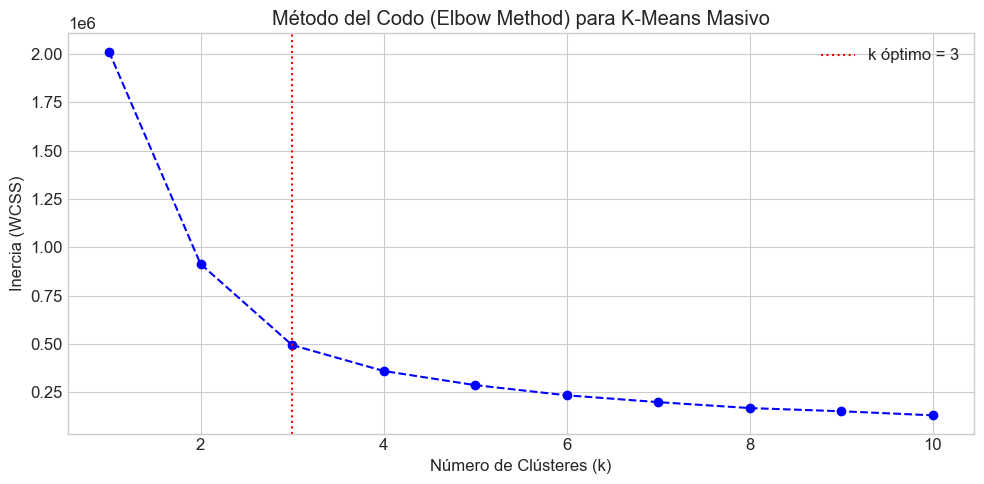

In [ ]:
# Método del Codo (Elbow Method) sobre una muestra masiva
inercia = []
rango_k = range(1, 11)

# se usa una muestra del 10% para que el ciclo no tarde horas en la PC
muestra_scaled = df_masivo_scaled.sample(frac=0.1, random_state=42)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans_temp.fit(muestra_scaled)
    inercia.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Elbow Method) para K-Means Masivo')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (WCSS)')
plt.axvline(x=3, color='r', linestyle=':', label='k óptimo = 3')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 3. Entrenar K-Means con k=3 en todo el dataset masivo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_masivo['Cluster'] = kmeans.fit_predict(df_masivo_scaled)

# 4. Asignar colores lógicos (Rojo al cluster con menor AC Power, Verde al de mayor)
cluster_ac_means = df_masivo.groupby('Cluster')['ac_power'].mean().sort_values()
color_map = {
    cluster_ac_means.index[0]: 'red',    # Falla Crítica (Alta corriente, baja potencia)
    cluster_ac_means.index[1]: 'orange', # Transición o Baja Irradiancia
    cluster_ac_means.index[2]: 'green'   # Operación Óptima
}
df_masivo['Color'] = df_masivo['Cluster'].map(color_map)


# 5. Visualización 3D Interactiva
# Para evitar crashear el navegador con millones de polígonos 3D, 
# se toma una muestra representativa densa de 20,000 puntos
df_plot = df_masivo.sample(n=min(20000, len(df_masivo)), random_state=42)

# Crear figura interactiva con Plotly (Usando dimensiones físicas reales, no PCA)
fig = go.Figure()

# Inversores (Nube Masiva)
textos_flotantes = [f"Inv: {inv}<br>Cluster: {c}" for inv, c in zip(df_plot['inversor_id'], df_plot['Color'])]

fig.add_trace(go.Scatter3d(
    x=df_plot['dc_current'],
    y=df_plot['dc_voltage'],
    z=df_plot['ac_power'],
    mode='markers',
    hovertext=textos_flotantes,
    hoverinfo='text',
    marker=dict(
        size=4,
        color=df_plot['Color'],
        opacity=0.6,
        line=dict(width=0)
    ),
    name='Observaciones Eléctricas'
))

# Transformar los centroides (que están escalados) a su valor físico real
centroides_reales = scaler.inverse_transform(kmeans.cluster_centers_)

# Centroides (Cruces Negras)
fig.add_trace(go.Scatter3d(
    x=centroides_reales[:, 1], # dc_current
    y=centroides_reales[:, 0], # dc_voltage
    z=centroides_reales[:, 2], # ac_power
    mode='markers+text',
    text=['C1', 'C2', 'C3'],
    textposition='top center',
    marker=dict(
        size=10,
        color='black',
        symbol='x',
        opacity=1.0,
        line=dict(width=4, color='black')
    ),
    name='Centroides (Físicos)'
))

fig.update_layout(
    title='Clusters K-Means en 3D con Centroides (Diagnóstico Físico)',
    scene=dict(xaxis_title='Corriente DC (A)', yaxis_title='Voltaje DC (V)', zaxis_title='Potencia AC (kW)'),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(itemsizing='constant')
)

# Exportar a archivo HTML interactivo
fig.write_html('clustering_3d_interactivo.html')
print("¡Gráfica masiva física exportada exitosamente como 'clustering_3d_interactivo.html'!")


¡Gráfica masiva física exportada exitosamente como 'clustering_3d_interactivo.html'!


### 4.2 Aprendizaje Supervisado: Random Forest vs Regresión Lineal
Una vez realizada la limpieza, se va a implementar la **Selección de Variables (Feature Selection)**. Se eliminará el Voltaje (baja correlación) y la Corriente AC (Data Leakage). 
Se va a poner a competir a dos algoritmos para predecir la Potencia AC generada por la planta.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Feature Selection: Se crea un dataset limpio solo con las variables maestras
# Tomar el promedio de toda la planta para hacer un modelo global
df_ml = pd.DataFrame(index=df_dia.index)
df_ml['hora'] = df_dia.index.hour
df_ml['mes'] = df_dia.index.month

# Extraer el promedio de DC Current de todos los inversores sanos
cols_dc_current = [c for c in df_dia.columns if 'dc_current' in c]
df_ml['dc_current_promedio'] = df_dia[cols_dc_current].mean(axis=1)

# Variable Objetivo (Y)
df_ml['target_ac_power'] = df_dia['mean_ac_power']

# Limpiar nulos causados por apagones
df_ml = df_ml.dropna()

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X = df_ml[['hora', 'mes', 'dc_current_promedio']]
y = df_ml['target_ac_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Set de Entrenamiento: {X_train.shape[0]} muestras. Set de Prueba: {X_test.shape[0]} muestras.")


Set de Entrenamiento: 276068 muestras. Set de Prueba: 69018 muestras.


In [14]:
from sklearn.linear_model import LinearRegression

# Entrenar Regresión Lineal (Modelo 1)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predicciones
y_pred_lr = lin_reg.predict(X_test)

# Métricas Matemáticas
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"--- REGRESIÓN LINEAL ---")
print(f"R2 Score: {r2_lr:.4f} (El modelo explica el {r2_lr*100:.2f}% de la varianza)")
print(f"RMSE: {rmse_lr:.4f} kW de error promedio")


--- REGRESIÓN LINEAL ---
R2 Score: 0.0084 (El modelo explica el 0.84% de la varianza)
RMSE: 10.2257 kW de error promedio


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Entrenar Random Forest (Modelo 2) con GridSearchCV para ajuste automático de parámetros
# Reducir los parámetros a probar para que corra rápido en clase
rf = RandomForestRegressor(random_state=42)
parametros_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

print("Iniciando ajuste de parámetros con GridSearchCV... (Esto puede tomar unos segundos)")
grid_search = GridSearchCV(estimator=rf, param_grid=parametros_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# El mejor modelo encontrado por el GridSearch
best_rf = grid_search.best_estimator_

# Predicciones
y_pred_rf = best_rf.predict(X_test)

# Métricas Matemáticas
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"\n--- RANDOM FOREST ---")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"R2 Score: {r2_rf:.4f} (El modelo explica el {r2_rf*100:.2f}% de la varianza)")
print(f"RMSE: {rmse_rf:.4f} kW de error promedio")


Iniciando ajuste de parámetros con GridSearchCV... (Esto puede tomar unos segundos)

--- RANDOM FOREST ---
Mejores parámetros encontrados: {'max_depth': 10, 'n_estimators': 50}
R2 Score: 0.9973 (El modelo explica el 99.73% de la varianza)
RMSE: 0.5349 kW de error promedio


,Modelo,R2 Score,RMSE (Error kW)
1,Random Forest,0.997287,0.534877
0,Regresión Lineal,0.008396,10.225691


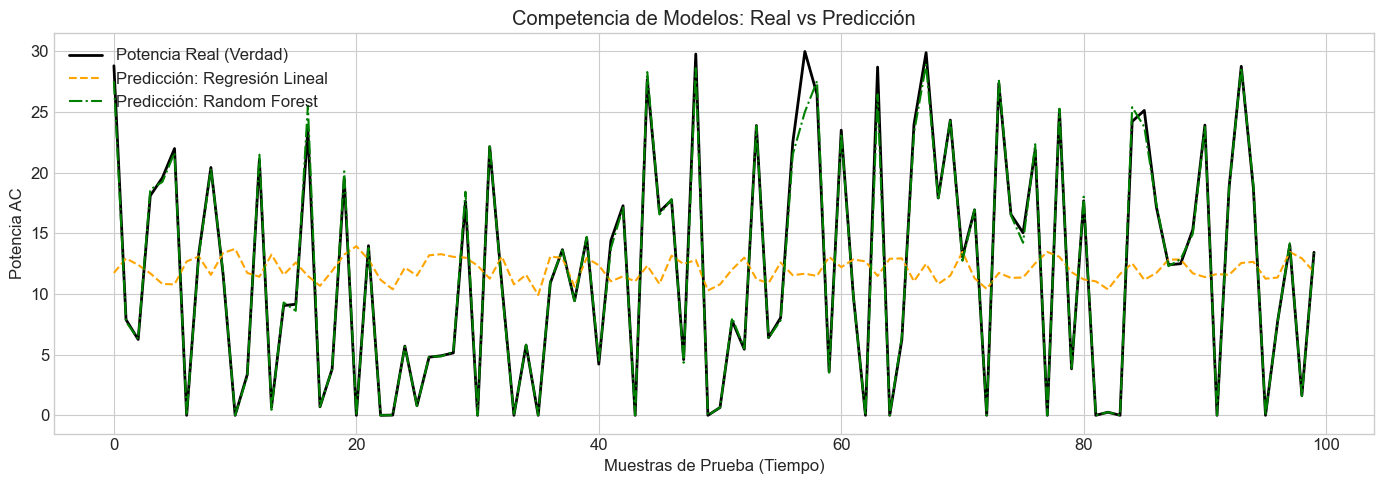

Veredicto del Algoritmo: El modelo ganador definitivo es Random Forest.


In [16]:
# Comparación final de Modelos
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'R2 Score': [r2_lr, r2_rf],
    'RMSE (Error kW)': [rmse_lr, rmse_rf]
})

display(resultados.sort_values(by='R2 Score', ascending=False))

# Gráfica de Valor Real vs Predicción (Solo los primeros 100 datos para ver claridad)
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label='Potencia Real (Verdad)', color='black', linewidth=2)
plt.plot(y_pred_lr[:100], label='Predicción: Regresión Lineal', color='orange', linestyle='--')
plt.plot(y_pred_rf[:100], label='Predicción: Random Forest', color='green', linestyle='-.')

plt.title('Competencia de Modelos: Real vs Predicción')
plt.ylabel('Potencia AC')
plt.xlabel('Muestras de Prueba (Tiempo)')
plt.legend()
plt.tight_layout()
plt.show()

ganador = "Random Forest" if r2_rf > r2_lr else "Regresión Lineal"
print(f"Veredicto del Algoritmo: El modelo ganador definitivo es {ganador}.")


### 4.3 Forecasting (Series de Tiempo con Prophet)
Para predecir a largo plazo, se va a utilizar la librería `prophet` de Facebook. A diferencia del Random Forest (que predice basándose en sensores climáticos/eléctricos), Prophet intentará adivinar el futuro **exclusivamente leyendo el patrón del tiempo** (estacionalidad y tendencias históricas).

22:18:35 - cmdstanpy - INFO - Chain [1] start processing
22:18:35 - cmdstanpy - INFO - Chain [1] done processing


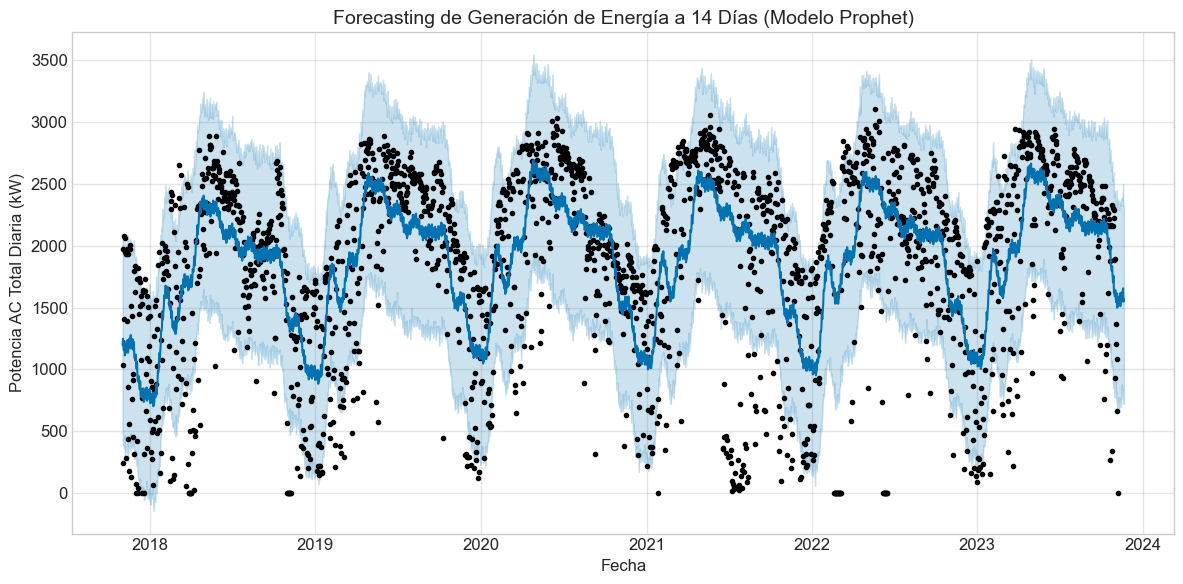

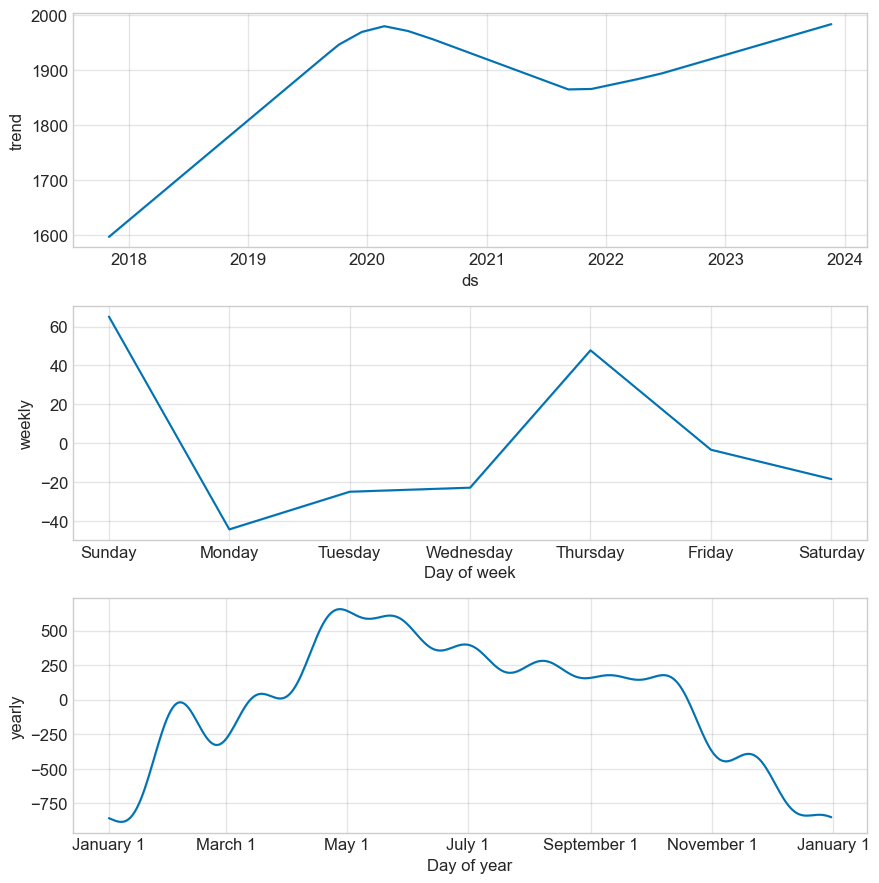

¡Forecasting completado! Las sombras azules en la gráfica indican el intervalo de confianza (incertidumbre matemática) de la predicción futura a 14 días.


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd

df_ts = pd.DataFrame()
df_ts['y'] = df_dia['mean_ac_power'].resample('D').sum()
df_ts['ds'] = df_ts.index

# Limpiar posibles nulos causados por apagones de días enteros
df_ts = df_ts.dropna()

# Prophet es excelente descubriendo estacionalidades diarias, semanales y anuales.
modelo_prophet = Prophet(
    daily_seasonality=False, # SE agrupó por día, no hay estacionalidad diaria intra-día
    yearly_seasonality=True, # El sol cambia con las estaciones del año
    weekly_seasonality=True  # Puede haber patrones semanales de mantenimiento
)
modelo_prophet.fit(df_ts)

# 3. Crear el "Futuro" a predecir (14 días adelante)
futuro = modelo_prophet.make_future_dataframe(periods=14, freq='D')

# 4. Realizar el Forecasting
prediccion = modelo_prophet.predict(futuro)

# 5. Visualizar el pronóstico
fig = modelo_prophet.plot(prediccion, figsize=(12, 6))
plt.title('Forecasting de Generación de Energía a 14 Días (Modelo Prophet)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Potencia AC Total Diaria (kW)', fontsize=12)
plt.tight_layout()
plt.show()

# Visualizar los componentes separados (Tendencia, Estacionalidad Semanal, Anual)
fig_comp = modelo_prophet.plot_components(prediccion)
plt.show()

print("¡Forecasting completado! Las sombras azules en la gráfica indican el intervalo de confianza (incertidumbre matemática) de la predicción futura a 14 días.")
